In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

/home/xz957/.conda/envs/sglang-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prepare Model & Calibrated KV-Cache

In [3]:
def load_model_and_tokenizer(model_name: str, device: str = "cuda", dtype=torch.float16, cache_dir: str = None):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, cache_dir=cache_dir)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map=device,
        trust_remote_code=True,
        cache_dir=cache_dir,
    )
    model.eval()

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    return model, tokenizer

In [4]:
NUM_SAMPLES = 100

In [5]:
model1_name = "qwen/qwen3-0.6b"
model2_name = "qwen/qwen3-1.7b"

model1, tokenizer1 = load_model_and_tokenizer(model1_name, cache_dir="/share/gupta/xz957/huggingface")
model1 = model1.eval().cuda()

`torch_dtype` is deprecated! Use `dtype` instead!


In [6]:
def with_kv_hook(model, run_inference):
    # We'll collect outputs for all layers in these lists
    collected_k_outputs = []
    collected_v_outputs = []
    collected_q_outputs = []
    def k_proj_hook(module, input, output):
        """
        module: The layer that produced this output (k_proj).
        input:  The input to k_proj.
        output: The output from k_proj (shape [batch_size, seq_len, hidden_dim]).
        """
        # Detach to avoid growing the autograd graph
        collected_k_outputs.append(output.detach().cpu())

    def v_proj_hook(module, input, output):
        """
        Same logic as k_proj_hook, but for v_proj.
        """
        collected_v_outputs.append(output.detach().cpu())
        
    def q_proj_hook(module, input, output):
        """
        Same logic as k_proj_hook, but for q_proj.
        """
        collected_q_outputs.append(output.detach().cpu())

    num_layers = len(model.model.layers)
    hooks_k = []
    hooks_v = []
    hooks_q = []
    for layer_idx in range(num_layers):
        # Access the i-th layer
        layer = model.model.layers[layer_idx].self_attn
        
        # Register forward hooks
        hook_k = layer.k_proj.register_forward_hook(k_proj_hook)
        hook_v = layer.v_proj.register_forward_hook(v_proj_hook)
        hook_q = layer.q_proj.register_forward_hook(q_proj_hook)
        
        hooks_k.append(hook_k)
        hooks_v.append(hook_v)
        hooks_q.append(hook_q)

    run_inference()

    for hook in hooks_k:
        hook.remove()
    for hook in hooks_v:
        hook.remove()
    for hook in hooks_q:
        hook.remove()
    
    return collected_k_outputs, collected_v_outputs

In [6]:
# # We'll collect outputs for all layers in these lists
# collected_k_outputs = []
# collected_v_outputs = []
# collected_q_outputs = []
# def k_proj_hook(module, input, output):
#     """
#     module: The layer that produced this output (k_proj).
#     input:  The input to k_proj.
#     output: The output from k_proj (shape [batch_size, seq_len, hidden_dim]).
#     """
#     # Detach to avoid growing the autograd graph
#     collected_k_outputs.append(output.detach().cpu())

# def v_proj_hook(module, input, output):
#     """
#     Same logic as k_proj_hook, but for v_proj.
#     """
#     collected_v_outputs.append(output.detach().cpu())
    
# def q_proj_hook(module, input, output):
#     """
#     Same logic as k_proj_hook, but for q_proj.
#     """
#     collected_q_outputs.append(output.detach().cpu())


In [7]:
# num_layers = len(model1.model.layers)
# hooks_k = []
# hooks_v = []
# hooks_q = []
# for layer_idx in range(num_layers):
#     # Access the i-th layer
#     layer = model1.model.layers[layer_idx].self_attn
    
#     # Register forward hooks
#     hook_k = layer.k_proj.register_forward_hook(k_proj_hook)
#     hook_v = layer.v_proj.register_forward_hook(v_proj_hook)
#     hook_q = layer.q_proj.register_forward_hook(q_proj_hook)
    
#     hooks_k.append(hook_k)
#     hooks_v.append(hook_v)
#     hooks_q.append(hook_q)

In [7]:
from datasets import load_dataset

dataset = load_dataset("trivia_qa", "rc", split="validation", cache_dir="/share/gupta/xz957/huggingface")
print(dataset)

Dataset({
    features: ['question', 'question_id', 'question_source', 'entity_pages', 'search_results', 'answer'],
    num_rows: 17944
})


In [9]:
# Print prompt lengths for each sample
tokenizer = AutoTokenizer.from_pretrained(model1_name, trust_remote_code=True, cache_dir="/share/gupta/xz957/huggingface")
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

lengths = []
for i, sample in enumerate(dataset):
    if i == NUM_SAMPLES:
        break
    prompt = f"Context: {str(sample['search_results']['search_context'])[:10000]}\n Question: {sample['question']}\n Answer:"
    input_ids = tokenizer(prompt, return_tensors="pt", truncation=True)["input_ids"]
    lengths.append(input_ids.shape[1])
    print(f"Sample {i}: prompt length = {input_ids.shape[1]} tokens")

print(f"\nPrompt length stats:")
print(f"  Min:  {min(lengths)}")
print(f"  Max:  {max(lengths)}")
print(f"  Mean: {sum(lengths) / len(lengths):.1f}")

Sample 0: prompt length = 2675 tokens
Sample 1: prompt length = 2597 tokens
Sample 2: prompt length = 1387 tokens
Sample 3: prompt length = 653 tokens
Sample 4: prompt length = 2427 tokens
Sample 5: prompt length = 2582 tokens
Sample 6: prompt length = 2196 tokens
Sample 7: prompt length = 2689 tokens
Sample 8: prompt length = 756 tokens
Sample 9: prompt length = 2513 tokens
Sample 10: prompt length = 2382 tokens
Sample 11: prompt length = 1199 tokens
Sample 12: prompt length = 2550 tokens
Sample 13: prompt length = 2338 tokens
Sample 14: prompt length = 2249 tokens
Sample 15: prompt length = 2167 tokens
Sample 16: prompt length = 1781 tokens
Sample 17: prompt length = 2323 tokens
Sample 18: prompt length = 25 tokens
Sample 19: prompt length = 2434 tokens
Sample 20: prompt length = 2445 tokens
Sample 21: prompt length = 2614 tokens
Sample 22: prompt length = 2450 tokens
Sample 23: prompt length = 2427 tokens
Sample 24: prompt length = 2877 tokens
Sample 25: prompt length = 2380 tokens


In [8]:
def run_samples(model, tokenizer):
    def run():
        with torch.no_grad():
            for i, sample in enumerate(dataset):
                if i == NUM_SAMPLES:
                    break
                print(f"Processing {i}")
                prompt = f"Context: {str(sample['search_results']['search_context'])[:10000]}\n Question: {sample['question']}\n Answer:"
                inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True)
                input_ids = inputs["input_ids"].cuda()
                attention_mask = inputs["attention_mask"].cuda()
                model(input_ids, attention_mask=attention_mask)
    return run

# Collect model1, then free it
k_outputs_model1, v_outputs_model1 = with_kv_hook(model1, run_samples(model1, tokenizer1))
del model1
torch.cuda.empty_cache()

# Load model2, collect, then free it
model2, tokenizer2 = load_model_and_tokenizer(model2_name, cache_dir="/share/gupta/xz957/huggingface")
model2 = model2.eval().cuda()
k_outputs_model2, v_outputs_model2 = with_kv_hook(model2, run_samples(model2, tokenizer2))
del model2
torch.cuda.empty_cache()

Processing 0
Processing 1
Processing 2
Processing 3
Processing 4
Processing 5
Processing 6
Processing 7
Processing 8
Processing 9
Processing 10
Processing 11
Processing 12
Processing 13
Processing 14


: 

: 

: 

In [ ]:
# Save KV tensors to disk for offline analysis
import os

SAVE_DIR = "/share/gupta/xz957/kvcache_tensors"
tag = f"{model1_name.replace('/', '_')}_vs_{model2_name.replace('/', '_')}_n{NUM_SAMPLES}"
save_path = os.path.join(SAVE_DIR, tag)
os.makedirs(save_path, exist_ok=True)

# Stack per-layer tensors: shape [NUM_SAMPLES, num_layers, 1, seq_len, d]
# But seq_len varies per sample, so save as list of tensors per (sample, layer)
# More practical: save per-layer, concatenating samples along dim 0

num_layers1 = len(k_outputs_model1) // NUM_SAMPLES
num_layers2 = len(k_outputs_model2) // NUM_SAMPLES

for layer_idx in range(num_layers1):
    k1 = torch.stack([k_outputs_model1[s * num_layers1 + layer_idx] for s in range(NUM_SAMPLES)])
    v1 = torch.stack([v_outputs_model1[s * num_layers1 + layer_idx] for s in range(NUM_SAMPLES)])
    torch.save(k1, os.path.join(save_path, f"k_model1_layer{layer_idx:02d}.pt"))
    torch.save(v1, os.path.join(save_path, f"v_model1_layer{layer_idx:02d}.pt"))

for layer_idx in range(num_layers2):
    k2 = torch.stack([k_outputs_model2[s * num_layers2 + layer_idx] for s in range(NUM_SAMPLES)])
    v2 = torch.stack([v_outputs_model2[s * num_layers2 + layer_idx] for s in range(NUM_SAMPLES)])
    torch.save(k2, os.path.join(save_path, f"k_model2_layer{layer_idx:02d}.pt"))
    torch.save(v2, os.path.join(save_path, f"v_model2_layer{layer_idx:02d}.pt"))

# Save metadata
import json as json_mod
meta = {
    "model1": model1_name,
    "model2": model2_name,
    "num_samples": NUM_SAMPLES,
    "num_layers1": num_layers1,
    "num_layers2": num_layers2,
    "shared_layers": min(num_layers1, num_layers2),
}
with open(os.path.join(save_path, "metadata.json"), "w") as f:
    json_mod.dump(meta, f, indent=2)

print(f"Saved to {save_path}")
print(f"Metadata: {meta}")
print(f"Files: {sorted(os.listdir(save_path))[:10]}... ({len(os.listdir(save_path))} total)")

## Analysis Function

In [12]:
def linear_cka_kernel(X: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    """
    Linear CKA using kernel formulation (Kornblith et al., 2019).

    Works across different embedding dimensions by computing n x n kernel matrices.
    X: (n, d1), Y: (n, d2) — n (tokens) must match, d1/d2 can differ.

    Returns: scalar CKA value in [0, 1].
    """
    # Center
    X = X - X.mean(dim=0, keepdim=True)
    Y = Y - Y.mean(dim=0, keepdim=True)

    # Kernel matrices (n x n)
    K = X @ X.T
    L = Y @ Y.T

    # HSIC and norms via Frobenius inner products
    hsic = (K * L).sum()
    norm_k = (K * K).sum().sqrt()
    norm_l = (L * L).sum().sqrt()

    if norm_k == 0 or norm_l == 0:
        return torch.tensor(0.0)

    return hsic / (norm_k * norm_l)


def principal_angle_subspace_similarity_torch(
    kv1: torch.Tensor, 
    kv2: torch.Tensor, 
    rank: int = None
) -> torch.Tensor:
    """
    Compute a subspace similarity between two matrices kv1, kv2 by comparing 
    their top-r principal components (SVD subspace).

    Steps:
      1. SVD each matrix kv1, kv2 => U1, S1, V1 and U2, S2, V2
      2. Truncate U1, U2 to top-`rank` columns (top singular vectors)
      3. Multiply M = U1_r^T @ U2_r
      4. SVD(M) => get singular values sigma_i
      5. Return average of (sigma_i^2) => a subspace overlap in [0,1]

    Args:
      kv1: shape (L, D)
      kv2: shape (L, D)
      rank: how many singular vectors to keep (top-r). If None, 
            we use min(L, D) for each input to get the full basis.

    Returns:
      subspace_sim: scalar tensor in [0,1], the average of sigma^2 over i.
                    1 => identical subspaces at that rank
    """
    # Determine default rank
    if rank is None:
        rank = min(kv1.shape[0], kv1.shape[1], kv2.shape[0], kv2.shape[1])

    # SVD (full_matrices=False) ensures shapes are (L, D) => (L, min(L,D))
    U1, S1, V1 = torch.svd_lowrank(kv1, q=rank)
    U2, S2, V2 = torch.svd_lowrank(kv2, q=rank)

    # Truncate
    U1_r = U1[:, :rank]  # shape (L, rank)
    U2_r = U2[:, :rank]  # shape (L, rank)

    # Multiply => shape (rank, rank)
    M = U1_r.transpose(0, 1) @ U2_r

    # SVD on M
    # The singular values of M measure how well subspaces overlap
    _, sigma, _ = torch.linalg.svd(M, full_matrices=False)

    # We return the average of sigma^2
    subspace_sim = (sigma**2).sum() / rank
    return subspace_sim

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tensor(w, ax=None, title=None, x_label="Dims", y_label="Token"):
    # Prepare the data for plotting
    x = np.arange(w.shape[0])  # Dims
    y = np.arange(w.shape[1])  # Seqlen
    x, y = np.meshgrid(x, y)

    # Use the provided axis or create a new figure and axis
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
    else:
        fig = None

    # Plot the surface
    surf = ax.plot_surface(x, y, w.T, cmap='coolwarm')
    ax.xaxis.set_tick_params(pad=-6, size=13)
    ax.yaxis.set_tick_params(pad=-4, size=13)
    ax.zaxis.set_tick_params(pad=-3, size=13)
    
    # Set title and labels
    if title is not None:
        ax.set_title(title, fontsize=15)
    ax.set_ylabel(x_label, labelpad=-5, fontsize=14)
    ax.set_xlabel(y_label, labelpad=-1, fontsize=14)
    ax.set_zlabel('Absolute Activation Value', labelpad=-5, fontsize=14)

    return fig

def plot_vector(w, ax=None, title=None, x_label="Dims", y_label="Value"):
    # Use the provided axis or create a new figure and axis
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111)
    else:
        fig = None

    # Plot the vector
    ax.plot(w)
    ax.xaxis.set_tick_params(size=16)
    ax.yaxis.set_tick_params(size=16)
    if x_label is not None:
        ax.set_xlabel(x_label, fontsize=14)
    if y_label is not None:
        ax.set_ylabel(y_label, fontsize=14)
    # Set title
    if title is not None:
        ax.set_title(title)

    return fig


def plot_side_by_side(tensors, titles=None, plot_type='tensor', saved_path = None):
    """
    Plot multiple tensors or vectors side by side.

    Args:
        tensors: List of tensors or vectors to plot.
        titles: List of titles for each plot (optional).
        plot_type: Type of plot ('tensor' for 3D tensor, 'vector' for 1D vector).
    """
    num_plots = len(tensors)
    fig, axs = plt.subplots(1, num_plots, figsize=(6 * num_plots + 3, 6), subplot_kw={'projection': '3d'} if plot_type == 'tensor' else {})

    # In case of only one plot, axs won't be an array; make it an array for consistency
    if num_plots == 1:
        axs = [axs]

    # Plot each tensor/vector
    for i, (tensor, ax) in enumerate(zip(tensors, axs)):
        title = titles[i] if titles is not None else None
        if plot_type == 'tensor':
            plot_tensor(tensor, ax=ax, title=title)
        elif plot_type == 'vector':
            plot_vector(tensor, ax=ax, title=title)
        else:
            raise ValueError("Unsupported plot type. Use 'tensor' or 'vector'.")

    plt.tight_layout()
    if saved_path is not None:
        plt.savefig(saved_path)
    plt.show()

In [14]:
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns

def plot_heatmap(tensor, title="Heatmap", custom_colors=None, colorbar=True, 
                 x_label="", y_label="", font_size=14, tick_font_size=12, interpolation="bilinear"):
    """
    Plots a smooth heatmap from a 2D PyTorch tensor with a custom color gradient.

    Args:
        tensor (torch.Tensor): 2D tensor to plot.
        title (str): Title of the heatmap.
        custom_colors (list): List of 6 colors for the colormap.
        colorbar (bool): Whether to show the colorbar.
        x_label (str): Label for the x-axis.
        y_label (str): Label for the y-axis.
        font_size (int): Font size for title and labels.
        tick_font_size (int): Font size for x and y ticks.
        interpolation (str): Interpolation method for smooth transitions (e.g., 'bilinear', 'bicubic').
    """
    if not isinstance(tensor, torch.Tensor):
        raise TypeError("Input must be a PyTorch tensor.")
    
    if tensor.dim() != 2:
        raise ValueError("Input tensor must be 2D.")
    
    # Convert tensor to numpy
    matrix = tensor.detach().cpu().numpy()

    # Define a custom colormap
    # if custom_colors and len(custom_colors) >= 2:
    #     cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", custom_colors, N=256)
    # else:
    #     cmap = "coolwarm"  # Default colormap if none provided

    cmap = sns.diverging_palette(240, 10, as_cmap=True)
    #cmap = sns.color_palette("vlag", as_cmap=True)
    #cmap = 'coolwarm'
    # Plot heatmap with smooth transitions
    plt.figure(figsize=(7, 6))
    im = plt.imshow(matrix, cmap=cmap, aspect='auto')

    # Set title and labels
    plt.title(title, fontsize=23)
    plt.xlabel(x_label, fontsize=21)
    plt.ylabel(y_label, fontsize=21)
    
    # Configure tick parameters
    plt.xticks(fontsize=19)
    plt.yticks(fontsize=19)

    # Configure colorbar
    if colorbar:
        cbar = plt.colorbar(im)
        cbar.ax.tick_params(labelsize=19)
    plt.savefig(f"{title}.pdf", bbox_inches='tight')
    plt.show()

In [15]:
num_layers1 = len(k_outputs_model1) // NUM_SAMPLES
num_layers2 = len(k_outputs_model2) // NUM_SAMPLES
shared_layers = min(num_layers1, num_layers2)

def compute_cka(mode):
    outputs_m1 = k_outputs_model1 if mode == "Key" else v_outputs_model1
    outputs_m2 = k_outputs_model2 if mode == "Key" else v_outputs_model2

    cka_per_layer = torch.zeros(shared_layers)

    for layer_idx in range(shared_layers):
        cka_values = []
        for s in range(NUM_SAMPLES):
            rep1 = outputs_m1[s * num_layers1 + layer_idx].squeeze(0).float()
            rep2 = outputs_m2[s * num_layers2 + layer_idx].squeeze(0).float()
            # print(rep1.shape, rep2.shape)

            cka_val = linear_cka_kernel(rep1, rep2)
            # cka_val = principal_angle_subspace_similarity_torch(rep1, rep2, rank=128)   
            cka_values.append(cka_val.item())

        cka_per_layer[layer_idx] = np.mean(cka_values)
        print(f"Layer {layer_idx:3d}: CKA = {cka_per_layer[layer_idx]:.4f}")
    return cka_per_layer

In [16]:
# cka_key = compute_cka("Key")
# cka_value = compute_cka("Value")

# shared_layers = len(cka_key)
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(range(shared_layers), cka_key.numpy(), marker="o", markersize=4, linewidth=1.5, label="Key-Cache")
# ax.plot(range(shared_layers), cka_value.numpy(), marker="s", markersize=4, linewidth=1.5, label="Value-Cache")
# ax.set_xlabel("Layer Index", fontsize=14)
# ax.set_ylabel("CKA Similarity", fontsize=14)
# ax.set_title(f"Cross-Model CKA\n{model1_name} vs {model2_name}", fontsize=16)
# ax.set_ylim(0, 1.05)
# ax.legend(fontsize=13)
# ax.grid(True, alpha=0.3)
# ax.tick_params(labelsize=12)
# plt.tight_layout()
# # plt.savefig(f"/home/xz957/autogen/python/packages/agbench/kvcache-study/results/cross-model-cka-4b-8b.jpg")
# plt.show()

Layer   0: CKA = 0.9535
Layer   1: CKA = 0.9488
Layer   2: CKA = 0.9490
Layer   3: CKA = 0.9228
Layer   4: CKA = 0.9273
Layer   5: CKA = 0.9349
Layer   6: CKA = 0.8974
Layer   7: CKA = 0.9032
Layer   8: CKA = 0.3842
Layer   9: CKA = 0.8405
Layer  10: CKA = 0.6601
Layer  11: CKA = 0.7313
Layer  12: CKA = 0.3158
Layer  13: CKA = 0.3620
Layer  14: CKA = 0.3437
Layer  15: CKA = 0.8402
Layer  16: CKA = 0.8686
Layer  17: CKA = 0.8528


KeyboardInterrupt: 

In [ ]:
def compute_cosine_sim(mode):
    outputs_m1 = k_outputs_model1 if mode == "Key" else v_outputs_model1
    outputs_m2 = k_outputs_model2 if mode == "Key" else v_outputs_model2

    cos_per_layer = torch.zeros(shared_layers)

    for layer_idx in range(shared_layers):
        cos_values = []
        for s in range(NUM_SAMPLES):
            rep1 = outputs_m1[s * num_layers1 + layer_idx].squeeze(0).float().flatten()
            rep2 = outputs_m2[s * num_layers2 + layer_idx].squeeze(0).float().flatten()

            cos_val = torch.nn.functional.cosine_similarity(rep1.unsqueeze(0), rep2.unsqueeze(0)).item()
            cos_values.append(cos_val)

        cos_per_layer[layer_idx] = np.mean(cos_values)
        print(f"Layer {layer_idx:3d}: Cosine Sim = {cos_per_layer[layer_idx]:.4f}")
    return cos_per_layer

# cos_key = compute_cosine_sim("Key")
# cos_value = compute_cosine_sim("Value")

Layer   0: Cosine Sim = 0.6650
Layer   1: Cosine Sim = 0.5782
Layer   2: Cosine Sim = 0.6772
Layer   3: Cosine Sim = 0.6066
Layer   4: Cosine Sim = 0.6093
Layer   5: Cosine Sim = 0.6113
Layer   6: Cosine Sim = 0.6417
Layer   7: Cosine Sim = 0.5219
Layer   8: Cosine Sim = 0.3953
Layer   9: Cosine Sim = 0.5678
Layer  10: Cosine Sim = 0.5058
Layer  11: Cosine Sim = 0.5252
Layer  12: Cosine Sim = 0.4729
Layer  13: Cosine Sim = 0.5112
Layer  14: Cosine Sim = 0.4989
Layer  15: Cosine Sim = 0.5992
Layer  16: Cosine Sim = 0.6986
Layer  17: Cosine Sim = 0.6905
Layer  18: Cosine Sim = 0.6548
Layer  19: Cosine Sim = 0.6934
Layer  20: Cosine Sim = 0.6249
Layer  21: Cosine Sim = 0.5378
Layer  22: Cosine Sim = 0.6120
Layer  23: Cosine Sim = 0.6141
Layer  24: Cosine Sim = 0.5785
Layer  25: Cosine Sim = 0.5820
Layer  26: Cosine Sim = 0.5514
Layer  27: Cosine Sim = 0.5687
Layer   0: Cosine Sim = 0.0905
Layer   1: Cosine Sim = 0.0691
Layer   2: Cosine Sim = 0.0759
Layer   3: Cosine Sim = 0.0786
Layer   

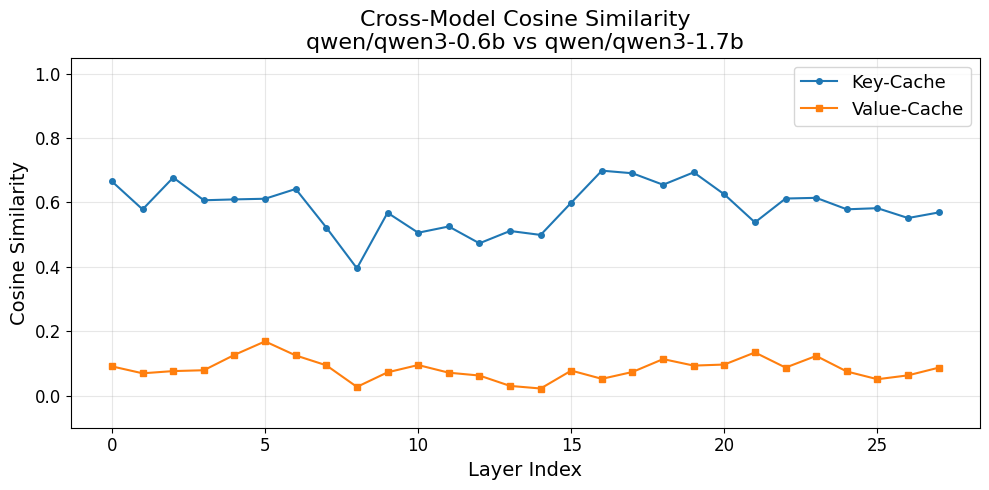

In [ ]:
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(range(shared_layers), cos_key.numpy(), marker='o', markersize=4, linewidth=1.5, label='Key-Cache')
# ax.plot(range(shared_layers), cos_value.numpy(), marker='s', markersize=4, linewidth=1.5, label='Value-Cache')
# ax.set_xlabel('Layer Index', fontsize=14)
# ax.set_ylabel('Cosine Similarity', fontsize=14)
# ax.set_title(f'Cross-Model Cosine Similarity\n{model1_name} vs {model2_name}', fontsize=16)
# ax.set_ylim(-0.1, 1.05)
# ax.legend(fontsize=13)
# ax.grid(True, alpha=0.3)
# ax.tick_params(labelsize=12)
# plt.tight_layout()
# plt.show()


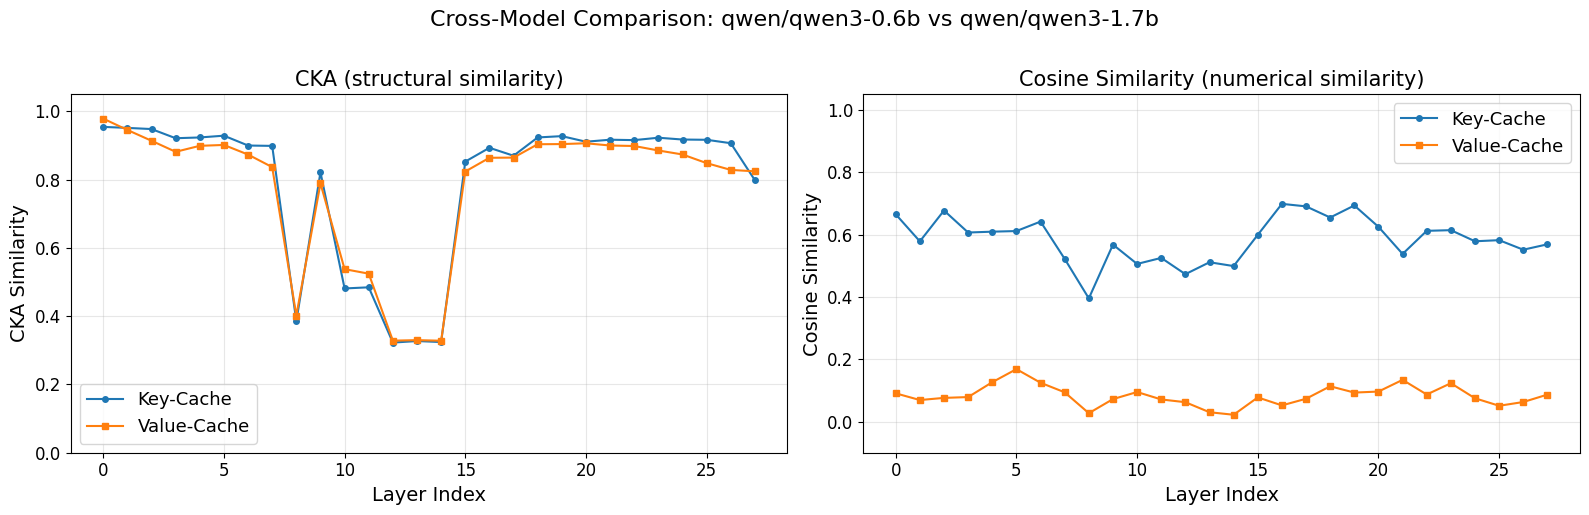

In [ ]:
# # Combined plot: CKA vs Cosine Similarity
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# # Left: CKA
# axes[0].plot(range(shared_layers), cka_key.numpy(), marker='o', ms=4, lw=1.5, label='Key-Cache')
# axes[0].plot(range(shared_layers), cka_value.numpy(), marker='s', ms=4, lw=1.5, label='Value-Cache')
# axes[0].set_xlabel('Layer Index', fontsize=14)
# axes[0].set_ylabel('CKA Similarity', fontsize=14)
# axes[0].set_title('CKA (structural similarity)', fontsize=15)
# axes[0].set_ylim(0, 1.05)
# axes[0].legend(fontsize=13)
# axes[0].grid(True, alpha=0.3)
# axes[0].tick_params(labelsize=12)

# # Right: Cosine Similarity
# axes[1].plot(range(shared_layers), cos_key.numpy(), marker='o', ms=4, lw=1.5, label='Key-Cache')
# axes[1].plot(range(shared_layers), cos_value.numpy(), marker='s', ms=4, lw=1.5, label='Value-Cache')
# axes[1].set_xlabel('Layer Index', fontsize=14)
# axes[1].set_ylabel('Cosine Similarity', fontsize=14)
# axes[1].set_title('Cosine Similarity (numerical similarity)', fontsize=15)
# axes[1].set_ylim(-0.1, 1.05)
# axes[1].legend(fontsize=13)
# axes[1].grid(True, alpha=0.3)
# axes[1].tick_params(labelsize=12)

# plt.suptitle(f'Cross-Model Comparison: {model1_name} vs {model2_name}', fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()


# Verify shared low-rank space

Steps:
1. Concatenate two matrices, M1 [seq_len, 1024] and M2 [seq_len, 1024], one from small model and one from bigger model. The result should look like [seq_len, 2048].
2. Do SVD on it, getting A and B, A being [2048, r] and B being [r, 2048]. We can toggle r later but right now assume it is full rank.
3. Construct back M1 and M2, compute the MSE for both.


In [23]:
import matplotlib.pyplot as plt
import numpy as np

NUM_SAMPLES = 1
rank_range = list(range(512, 2048, 256))  # ranks to sweep

In [24]:
# Verify shared low-rank space: joint vs individual SVD reconstruction
results = {}       # joint:      results[(mode, layer_idx)] = {"ranks", "mse_m1", "mse_m2"}
results_indiv = {} # individual: results_indiv[(mode, layer_idx)] = {"ranks", "mse_m1", "mse_m2"}

for mode in ["Key", "Value"]:
    outputs_m1 = k_outputs_model1 if mode == "Key" else v_outputs_model1
    outputs_m2 = k_outputs_model2 if mode == "Key" else v_outputs_model2

    for layer_idx in range(shared_layers):
        # Accumulators for joint SVD
        mse_m1_joint = np.zeros(len(rank_range))
        mse_m2_joint = np.zeros(len(rank_range))
        # Accumulators for individual SVD
        mse_m1_indiv = np.zeros(len(rank_range))
        mse_m2_indiv = np.zeros(len(rank_range))

        for s in range(NUM_SAMPLES):
            M1 = outputs_m1[s * num_layers1 + layer_idx].squeeze(0).float()  # [seq_len, d1]
            M2 = outputs_m2[s * num_layers2 + layer_idx].squeeze(0).float()  # [seq_len, d2]
            d1 = M1.shape[1]

            # --- Joint SVD ---
            M_cat = torch.cat([M1, M2], dim=1)  # [seq_len, d1+d2]
            U_j, S_j, Vh_j = torch.linalg.svd(M_cat, full_matrices=False)

            # --- Individual SVDs ---
            U1, S1, Vh1 = torch.linalg.svd(M1, full_matrices=False)
            U2, S2, Vh2 = torch.linalg.svd(M2, full_matrices=False)

            for ri, r in enumerate(rank_range):
                # Joint reconstruction
                r_j = min(r, len(S_j))
                M_cat_approx = U_j[:, :r_j] @ torch.diag(S_j[:r_j]) @ Vh_j[:r_j, :]
                mse_m1_joint[ri] += ((M1 - M_cat_approx[:, :d1]) ** 2).mean().item()
                mse_m2_joint[ri] += ((M2 - M_cat_approx[:, d1:]) ** 2).mean().item()

                # Individual reconstruction
                r1 = min(r, len(S1))
                M1_approx = U1[:, :r1] @ torch.diag(S1[:r1]) @ Vh1[:r1, :]
                mse_m1_indiv[ri] += ((M1 - M1_approx) ** 2).mean().item()

                r2 = min(r, len(S2))
                M2_approx = U2[:, :r2] @ torch.diag(S2[:r2]) @ Vh2[:r2, :]
                mse_m2_indiv[ri] += ((M2 - M2_approx) ** 2).mean().item()

        results[(mode, layer_idx)] = {
            "ranks": rank_range,
            "mse_m1": (mse_m1_joint / NUM_SAMPLES).tolist(),
            "mse_m2": (mse_m2_joint / NUM_SAMPLES).tolist(),
        }
        results_indiv[(mode, layer_idx)] = {
            "ranks": rank_range,
            "mse_m1": (mse_m1_indiv / NUM_SAMPLES).tolist(),
            "mse_m2": (mse_m2_indiv / NUM_SAMPLES).tolist(),
        }

        print(f"[{mode}] Layer {layer_idx:2d}: "
              f"Joint MSE@r={rank_range[0]} m1={results[(mode,layer_idx)]['mse_m1'][0]:.6f} m2={results[(mode,layer_idx)]['mse_m2'][0]:.6f}  |  "
              f"Indiv MSE@r={rank_range[0]} m1={results_indiv[(mode,layer_idx)]['mse_m1'][0]:.6f} m2={results_indiv[(mode,layer_idx)]['mse_m2'][0]:.6f}")
    print()

[Key] Layer  0: Joint MSE@r=512 m1=0.000574 m2=0.000721  |  Indiv MSE@r=512 m1=0.000234 m2=0.000316
[Key] Layer  1: Joint MSE@r=512 m1=0.000384 m2=0.000490  |  Indiv MSE@r=512 m1=0.000089 m2=0.000229
[Key] Layer  2: Joint MSE@r=512 m1=0.000747 m2=0.000951  |  Indiv MSE@r=512 m1=0.000148 m2=0.000433
[Key] Layer  3: Joint MSE@r=512 m1=0.006540 m2=0.008286  |  Indiv MSE@r=512 m1=0.001389 m2=0.003512
[Key] Layer  4: Joint MSE@r=512 m1=0.006536 m2=0.008124  |  Indiv MSE@r=512 m1=0.001448 m2=0.003348
[Key] Layer  5: Joint MSE@r=512 m1=0.009336 m2=0.011722  |  Indiv MSE@r=512 m1=0.002132 m2=0.004871
[Key] Layer  6: Joint MSE@r=512 m1=0.006075 m2=0.007603  |  Indiv MSE@r=512 m1=0.000990 m2=0.002904
[Key] Layer  7: Joint MSE@r=512 m1=0.014920 m2=0.018938  |  Indiv MSE@r=512 m1=0.002826 m2=0.008760
[Key] Layer  8: Joint MSE@r=512 m1=0.015943 m2=0.020401  |  Indiv MSE@r=512 m1=0.002630 m2=0.008889
[Key] Layer  9: Joint MSE@r=512 m1=0.028575 m2=0.036600  |  Indiv MSE@r=512 m1=0.004707 m2=0.017013


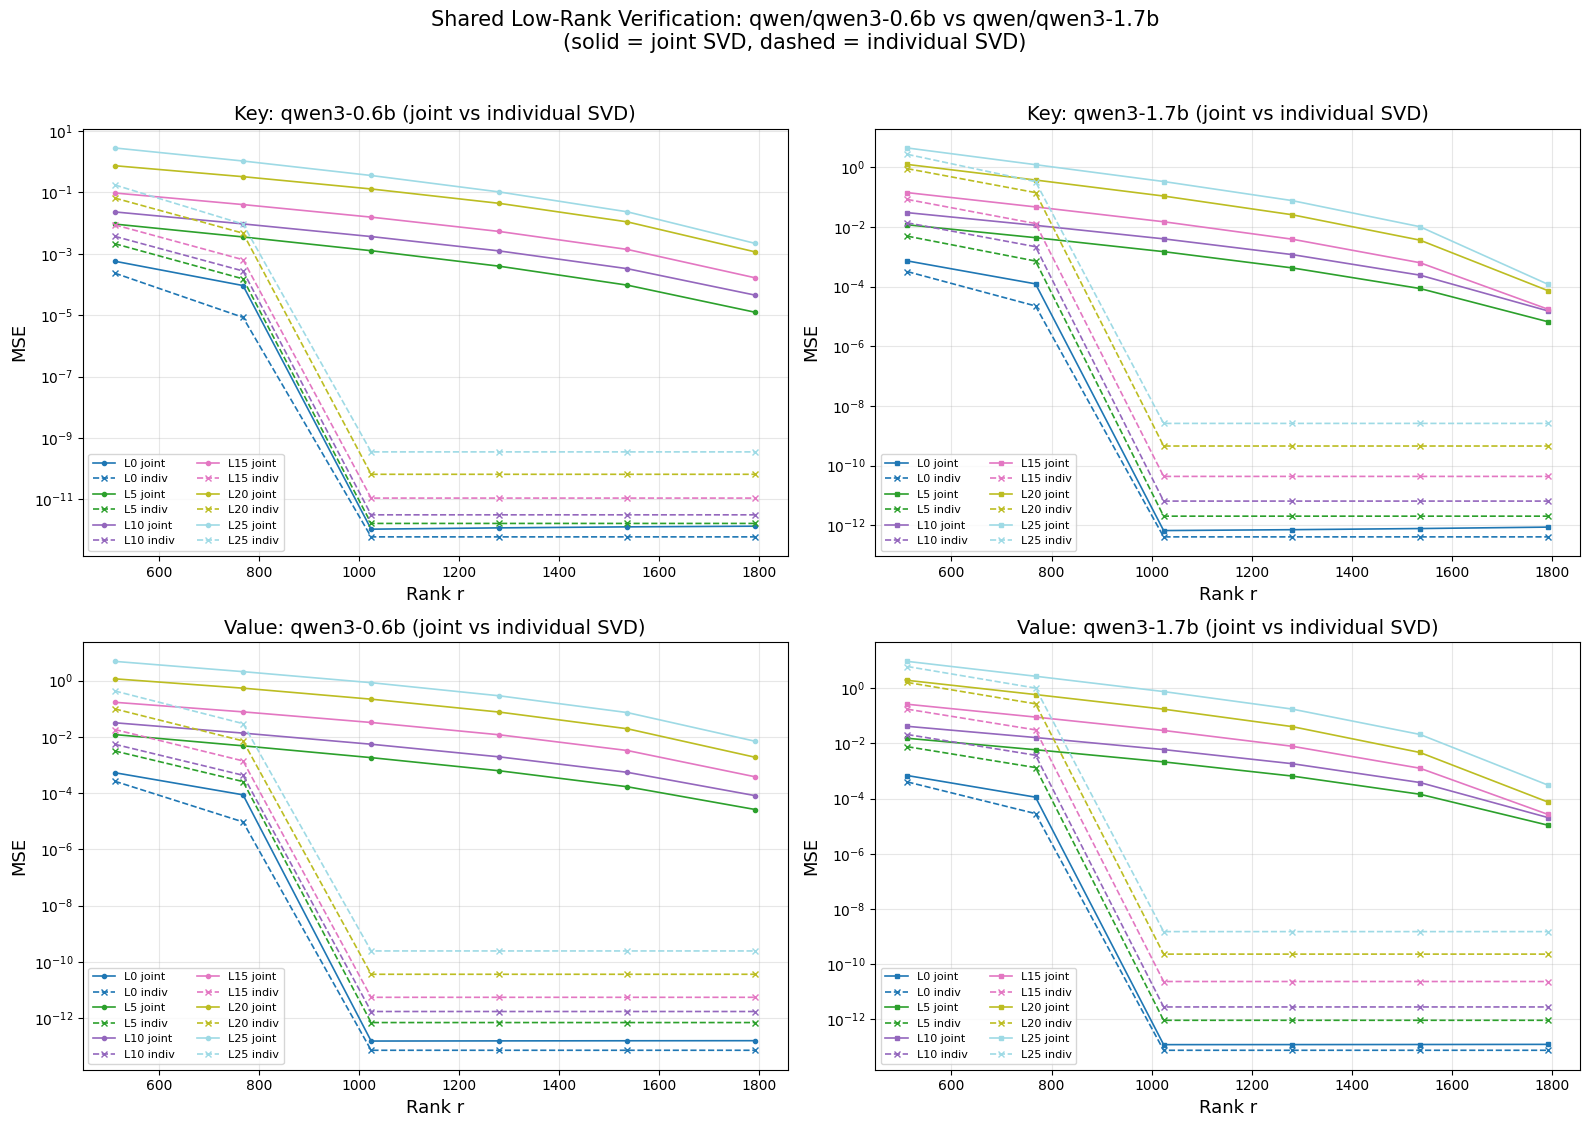

In [25]:
# Plot: Joint vs Individual SVD reconstruction MSE
selected_layers = list(range(0, shared_layers, 5))
colors = plt.cm.tab20(np.linspace(0, 1, len(selected_layers)))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for row, mode in enumerate(["Key", "Value"]):
    # Left: model1 (small)
    ax = axes[row, 0]
    for ci, layer_idx in enumerate(selected_layers):
        rj = results[(mode, layer_idx)]
        ri = results_indiv[(mode, layer_idx)]
        ax.plot(rj["ranks"], rj["mse_m1"], marker="o", ms=3, lw=1.2, color=colors[ci], label=f"L{layer_idx} joint")
        ax.plot(ri["ranks"], ri["mse_m1"], marker="x", ms=4, lw=1.2, ls="--", color=colors[ci], label=f"L{layer_idx} indiv")
    ax.set_xlabel("Rank r", fontsize=13)
    ax.set_ylabel("MSE", fontsize=13)
    ax.set_title(f"{mode}: {model1_name.split('/')[-1]} (joint vs individual SVD)", fontsize=14)
    ax.set_yscale("log")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

    # Right: model2 (large)
    ax = axes[row, 1]
    for ci, layer_idx in enumerate(selected_layers):
        rj = results[(mode, layer_idx)]
        ri = results_indiv[(mode, layer_idx)]
        ax.plot(rj["ranks"], rj["mse_m2"], marker="s", ms=3, lw=1.2, color=colors[ci], label=f"L{layer_idx} joint")
        ax.plot(ri["ranks"], ri["mse_m2"], marker="x", ms=4, lw=1.2, ls="--", color=colors[ci], label=f"L{layer_idx} indiv")
    ax.set_xlabel("Rank r", fontsize=13)
    ax.set_ylabel("MSE", fontsize=13)
    ax.set_title(f"{mode}: {model2_name.split('/')[-1]} (joint vs individual SVD)", fontsize=14)
    ax.set_yscale("log")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Shared Low-Rank Verification: {model1_name} vs {model2_name}\n(solid = joint SVD, dashed = individual SVD)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Reconstruct M_1 from M_2
Given:
- M_1 = AB_1
- M_2 = AB_2
- M_1 is known

We want to compute M_1: $M_1 = AB_1 = (M_2 B_2^T (B_2 B_2^T)^{-1}) B_1$

[Key] Layer  0: MSE=    0.162974  var(M1)=    0.162957  NMSE=1.000100
[Key] Layer  1: MSE=    0.036276  var(M1)=    0.036260  NMSE=1.000443
[Key] Layer  2: MSE=    0.071206  var(M1)=    0.071183  NMSE=1.000319
[Key] Layer  3: MSE=    0.302093  var(M1)=    0.302048  NMSE=1.000147
[Key] Layer  4: MSE=    0.438127  var(M1)=    0.438105  NMSE=1.000049
[Key] Layer  5: MSE=    0.601625  var(M1)=    0.601535  NMSE=1.000149
[Key] Layer  6: MSE=    0.338970  var(M1)=    0.338968  NMSE=1.000005
[Key] Layer  7: MSE=    0.679468  var(M1)=    0.679029  NMSE=1.000646
[Key] Layer  8: MSE=    0.752181  var(M1)=    0.752168  NMSE=1.000018
[Key] Layer  9: MSE=    1.198099  var(M1)=    1.197903  NMSE=1.000164
[Key] Layer 10: MSE=    1.164683  var(M1)=    1.162552  NMSE=1.001833
[Key] Layer 11: MSE=    2.096010  var(M1)=    2.095389  NMSE=1.000296
[Key] Layer 12: MSE=    2.133399  var(M1)=    2.133198  NMSE=1.000094
[Key] Layer 13: MSE=    2.314945  var(M1)=    2.313655  NMSE=1.000558
[Key] Layer 14: MSE=

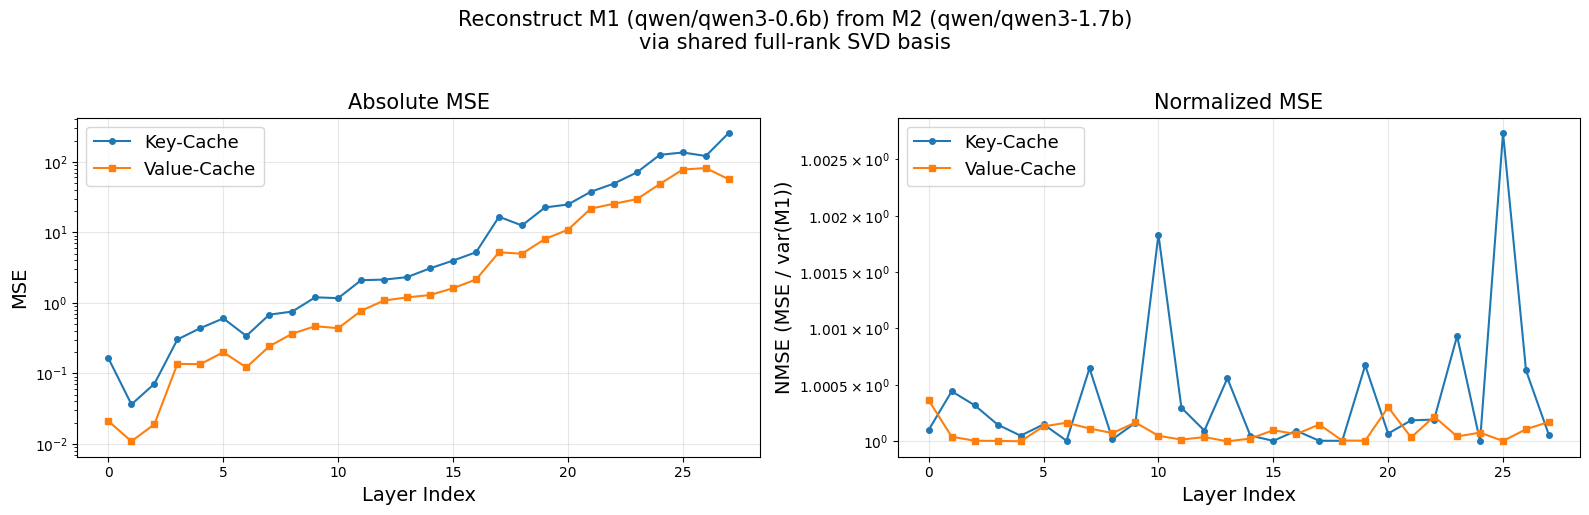

In [28]:
# Reconstruct M_1 from M_2 using shared SVD basis (full rank)
#
# From joint SVD of [M1 | M2]:  [M1 | M2] = U @ diag(S) @ Vh
# Split Vh into B1 = Vh[:, :d1] and B2 = Vh[:, d1:]
# So:  M1 = U@diag(S) @ B1,  M2 = U@diag(S) @ B2
# Let A = U@diag(S).  Given M2, recover A = M2 @ pinv(B2), then M1_hat = A @ B1.
#
# We use pinv because B2 is [k, d2] with k = d1+d2 > d2, so B2 is tall
# and B2 @ B2^T is rank-deficient (rank d2) — direct inverse would blow up.

reconstruct_results = {}

for mode in ["Key", "Value"]:
    outputs_m1 = k_outputs_model1 if mode == "Key" else v_outputs_model1
    outputs_m2 = k_outputs_model2 if mode == "Key" else v_outputs_model2

    for layer_idx in range(shared_layers):
        mse_samples = []
        nmse_samples = []  # normalized MSE (MSE / var(M1))

        for s in range(NUM_SAMPLES):
            M1 = outputs_m1[s * num_layers1 + layer_idx].squeeze(0).float()  # [seq_len, d1]
            M2 = outputs_m2[s * num_layers2 + layer_idx].squeeze(0).float()  # [seq_len, d2]
            d1 = M1.shape[1]

            # Joint SVD (full rank)
            M_cat = torch.cat([M1, M2], dim=1)  # [seq_len, d1+d2]
            U, S, Vh = torch.linalg.svd(M_cat, full_matrices=False)

            # Split Vh into B1 and B2
            B1 = Vh[:, :d1]   # [k, d1]
            B2 = Vh[:, d1:]   # [k, d2]

            # Recover A from M2 using pseudoinverse: A = M2 @ pinv(B2)
            A = M2 @ torch.linalg.pinv(B2)  # [seq_len, k]

            # Reconstruct M1
            M1_hat = A @ B1  # [seq_len, d1]

            mse = ((M1 - M1_hat) ** 2).mean().item()
            var_m1 = M1.var().item()
            mse_samples.append(mse)
            nmse_samples.append(mse / var_m1 if var_m1 > 0 else float('inf'))

        avg_mse = np.mean(mse_samples)
        avg_nmse = np.mean(nmse_samples)
        reconstruct_results[(mode, layer_idx)] = {
            "mse": avg_mse,
            "nmse": avg_nmse,
            "var_m1": np.mean([M1.var().item() for M1 in [outputs_m1[s * num_layers1 + layer_idx].squeeze(0).float() for s in range(NUM_SAMPLES)]]),
        }
        print(f"[{mode}] Layer {layer_idx:2d}: MSE={avg_mse:12.6f}  var(M1)={reconstruct_results[(mode,layer_idx)]['var_m1']:12.6f}  NMSE={avg_nmse:.6f}")
    print()

# Plot both absolute and normalized MSE
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for mode in ["Key", "Value"]:
    mses = [reconstruct_results[(mode, l)]["mse"] for l in range(shared_layers)]
    ax.plot(range(shared_layers), mses, marker="o" if mode == "Key" else "s", ms=4, lw=1.5, label=f"{mode}-Cache")
ax.set_xlabel("Layer Index", fontsize=14)
ax.set_ylabel("MSE", fontsize=14)
ax.set_title("Absolute MSE", fontsize=15)
ax.set_yscale("log")
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)

ax = axes[1]
for mode in ["Key", "Value"]:
    nmses = [reconstruct_results[(mode, l)]["nmse"] for l in range(shared_layers)]
    ax.plot(range(shared_layers), nmses, marker="o" if mode == "Key" else "s", ms=4, lw=1.5, label=f"{mode}-Cache")
ax.set_xlabel("Layer Index", fontsize=14)
ax.set_ylabel("NMSE (MSE / var(M1))", fontsize=14)
ax.set_title("Normalized MSE", fontsize=15)
ax.set_yscale("log")
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)

plt.suptitle(f"Reconstruct M1 ({model1_name}) from M2 ({model2_name})\nvia shared full-rank SVD basis", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Run SVD

Steps:
1. Find one pair of K tensor, the one from 0.6b model being K_s and the one from 1.7b model being K_t
2. Compute $W^*=(K_t^T \times ​K_t​)^{−1}\times K_t^T \times ​K_s​$
3. Do SVD on W^* to get U, R, V^T
4. Print and show if R is low-rank

In [ ]:
# # For each layer, compute the least-squares mapping W* from K_t to K_s,
# # then SVD to check if W* is low-rank.
# #
# # K_s: [seq_len, d] from small model, K_t: [seq_len, d] from large model
# # W* = (K_t^T K_t)^{-1} K_t^T K_s  (shape [d, d])
# # Then SVD(W*) = U @ diag(sigma) @ V^T

# # Average singular values across multiple samples for stability
# NUM_SVD_SAMPLES = min(0, NUM_SAMPLES)

# svd_results = {"Key": {}, "Value": {}}

# for mode in ["Key", "Value"]:
#     outputs_m1 = k_outputs_model1 if mode == "Key" else v_outputs_model1
#     outputs_m2 = k_outputs_model2 if mode == "Key" else v_outputs_model2

#     all_sigmas = []

#     for layer_idx in range(shared_layers):
#         sample_sigmas = []
#         for s in range(NUM_SVD_SAMPLES):
#             K_s = outputs_m1[s * num_layers1 + layer_idx].squeeze(0).float()  # [seq, d]
#             K_t = outputs_m2[s * num_layers2 + layer_idx].squeeze(0).float()  # [seq, d]

#             # Least-squares: W* = (K_t^T K_t)^{-1} K_t^T K_s
#             # Use torch.linalg.lstsq for numerical stability
#             W_star = torch.linalg.lstsq(K_t, K_s).solution  # [d, d]

#             # SVD of W*
#             U, sigma, Vh = torch.linalg.svd(W_star, full_matrices=False)
#             sample_sigmas.append(sigma.numpy())

#         avg_sigma = np.mean(sample_sigmas, axis=0)
#         svd_results[mode][layer_idx] = avg_sigma

#         # Print summary
#         total_energy = (avg_sigma ** 2).sum()
#         cumulative = np.cumsum(avg_sigma ** 2) / total_energy
#         rank_90 = np.searchsorted(cumulative, 0.90) + 1
#         rank_95 = np.searchsorted(cumulative, 0.95) + 1
#         rank_99 = np.searchsorted(cumulative, 0.99) + 1
#         print(f"[{mode}] Layer {layer_idx:2d}: rank@90%={rank_90:3d}  rank@95%={rank_95:3d}  "
#               f"rank@99%={rank_99:3d}  top-1={avg_sigma[0]:.4f}  dim={len(avg_sigma)}")

#     print()

/home/xz957/.conda/envs/sglang-env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/xz957/.conda/envs/sglang-env/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


IndexError: invalid index to scalar variable.

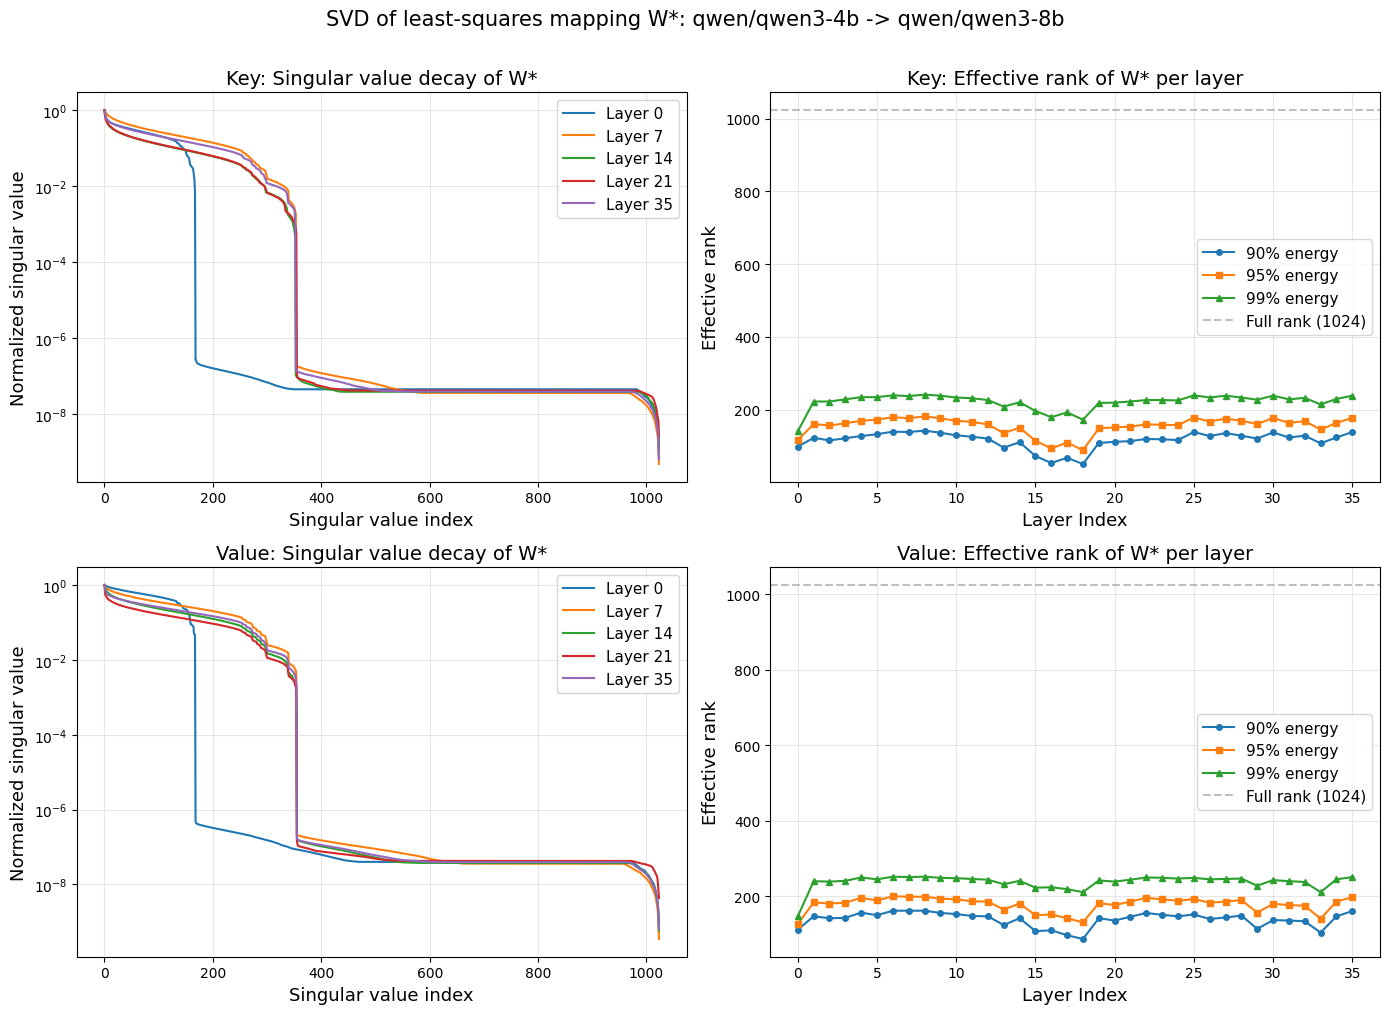

In [ ]:
# # Plot singular value spectra for selected layers
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# for row, mode in enumerate(["Key", "Value"]):
#     # Left: singular value decay for a few layers
#     ax = axes[row, 0]
#     for layer_idx in [0, 7, 14, 21, shared_layers - 1]:
#         sigma = svd_results[mode][layer_idx]
#         ax.plot(sigma / sigma[0], label=f"Layer {layer_idx}", linewidth=1.5)
#     ax.set_xlabel("Singular value index", fontsize=13)
#     ax.set_ylabel("Normalized singular value", fontsize=13)
#     ax.set_title(f"{mode}: Singular value decay of W*", fontsize=14)
#     ax.legend(fontsize=11)
#     ax.set_yscale("log")
#     ax.grid(True, alpha=0.3)

#     # Right: effective rank (90%, 95%, 99%) across layers
#     ax = axes[row, 1]
#     ranks = {"90%": [], "95%": [], "99%": []}
#     for layer_idx in range(shared_layers):
#         sigma = svd_results[mode][layer_idx]
#         total = (sigma ** 2).sum()
#         cum = np.cumsum(sigma ** 2) / total
#         ranks["90%"].append(np.searchsorted(cum, 0.90) + 1)
#         ranks["95%"].append(np.searchsorted(cum, 0.95) + 1)
#         ranks["99%"].append(np.searchsorted(cum, 0.99) + 1)

#     x = range(shared_layers)
#     ax.plot(x, ranks["90%"], marker="o", ms=4, lw=1.5, label="90% energy")
#     ax.plot(x, ranks["95%"], marker="s", ms=4, lw=1.5, label="95% energy")
#     ax.plot(x, ranks["99%"], marker="^", ms=4, lw=1.5, label="99% energy")
#     ax.axhline(len(svd_results[mode][0]), color="gray", ls="--", alpha=0.5, label=f"Full rank ({len(svd_results[mode][0])})")
#     ax.set_xlabel("Layer Index", fontsize=13)
#     ax.set_ylabel("Effective rank", fontsize=13)
#     ax.set_title(f"{mode}: Effective rank of W* per layer", fontsize=14)
#     ax.legend(fontsize=11)
#     ax.grid(True, alpha=0.3)

# plt.suptitle(f"SVD of least-squares mapping W*: {model1_name} -> {model2_name}", fontsize=15, y=1.01)
# plt.tight_layout()
# plt.show()


In [29]:
torch.cuda.empty_cache()